In [1]:
from google.colab import files
uploaded = files.upload()

Saving twitter_training.csv to twitter_training.csv
Saving twitter_validation.csv to twitter_validation.csv


In [2]:
import pandas as pd

# Load training data
train_df = pd.read_csv("twitter_training.csv", header=None)

# Load validation data
val_df = pd.read_csv("twitter_validation.csv", header=None)

print(train_df.head())

      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [3]:
columns = ["id", "topic", "sentiment", "text"]

train_df.columns = columns
val_df.columns = columns

print(train_df.head())

     id        topic sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [4]:
print(train_df.isnull().sum())

id             0
topic          0
sentiment      0
text         686
dtype: int64


In [5]:
train_df = train_df.dropna()
val_df = val_df.dropna()

In [6]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text"] = train_df["text"].apply(clean_text)
val_df["text"] = val_df["text"].apply(clean_text)

In [7]:
## preprocessing
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["label"] = le.fit_transform(train_df["sentiment"])
val_df["label"] = le.transform(val_df["sentiment"])

print(train_df[["sentiment", "label"]].head())

  sentiment  label
0  Positive      3
1  Positive      3
2  Positive      3
3  Positive      3
4  Positive      3


In [8]:
print(train_df.shape)
print(val_df.shape)
print(train_df["label"].value_counts())

(73996, 5)
(1000, 5)
label
1    22358
3    20655
2    18108
0    12875
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    train_df["text"],
    train_df["label"],
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"]
)

In [10]:
val_texts = val_df["text"]
val_labels = val_df["label"]

In [11]:
print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 66596
Validation size: 1000
Test size: 7400


In [12]:
!pip install transformers

from transformers import BertTokenizer
import torch

In [13]:
## why tokenization: BERT cannot understand raw text. It requires numerical input in the form of token IDs and attention masks, which are generated using a pre-trained tokenizer.

In [14]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
sample = train_texts.iloc[0]

encoding = tokenizer(
    sample,
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

print(encoding)

{'input_ids': tensor([[  101, 13749, 14074, 19000,  2003,  1037,  2591,  6960,  2008,  7126,
          8211,  2402,  2111,  2131,  2125,  1996,  4534,  1998,  5335,  2037,
          5177,  2740,  5466,  1037,  2261,  3866,  3924,  2037,  2126,  2011,
          2206,  2068,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

In [16]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [17]:
class TwitterDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [18]:
train_dataset = TwitterDataset(train_encodings, train_labels)
val_dataset = TwitterDataset(val_encodings, val_labels)
test_dataset = TwitterDataset(test_encodings, test_labels)

In [19]:
from transformers import AutoModelForSequenceClassification
import torch

In [20]:
num_labels = len(train_df["label"].unique())
print(num_labels)

4


In [21]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [23]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [24]:
from torch.optim import AdamW

In [25]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [27]:
from tqdm import tqdm

epochs = 2

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    print(f"Training Loss: {avg_loss:.4f}")


Epoch 1/2


100%|██████████| 4163/4163 [25:40<00:00,  2.70it/s]


Training Loss: 0.8259

Epoch 2/2


100%|██████████| 4163/4163 [25:51<00:00,  2.68it/s]

Training Loss: 0.3199


In [28]:
from sklearn.metrics import accuracy_score

model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

val_accuracy = accuracy_score(true_labels, predictions)
print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.974


In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

model.eval()

predictions, true_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

In [30]:
accuracy = accuracy_score(true_labels, predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, predictions, average='weighted'
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8941891891891892
Precision: 0.8955503857082495
Recall: 0.8941891891891892
F1 Score: 0.8939091503999412


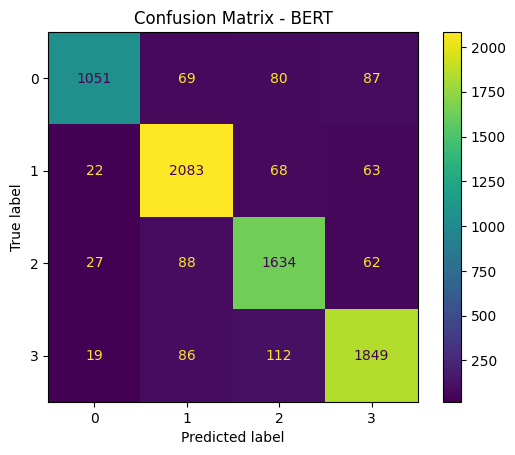

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - BERT")
plt.show()

In [32]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predictions, target_names=le.classes_))

              precision    recall  f1-score   support

  Irrelevant       0.94      0.82      0.87      1287
    Negative       0.90      0.93      0.91      2236
     Neutral       0.86      0.90      0.88      1811
    Positive       0.90      0.89      0.90      2066

    accuracy                           0.89      7400
   macro avg       0.90      0.89      0.89      7400
weighted avg       0.90      0.89      0.89      7400



# Conclusion
*The BERT model achieved strong performance on the Twitter sentiment dataset. The F1 score indicates a balanced performance across all classes. The confusion matrix shows that most predictions fall on the diagonal, meaning correct classification. Some misclassifications occur between similar sentiments like neutral and positive.*